###### 130_5_practical_recurrence_graph_answer.ipynb

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Meiryo"

In [9]:
df_defect = pd.DataFrame(
    [
        ["2026-06-01", "SUS", "J69P", "D-001", "コイル", 1],
        ["2026-06-02", "SUS", "J69P", "D-002", "コイル", 1],
        ["2026-06-03", "SUS", "J69P", "D-003", "Buck-IC", 1],
        ["2026-06-04", "SUS", "J69P", "D-004", "コイル", 1],
        ["2026-06-05", "SUS", "310D", "D-005", "NTF", 1],
        ["2026-06-06", "SUS", "310D", "D-006", "NTF", 1],
        ["2026-06-01", "WSE", "310D", "D-007", "コイル", 2],
        ["2026-06-03", "WSE", "310D", "D-008", "コイル", 1],
        ["2026-06-04", "WSE", "310D", "D-009", "CAN通信", 1],
        ["2026-06-06", "WSE", "310D", "D-010", "コイル", 1],
        ["2026-06-02", "GSE", "J69P", "D-011", "コイル", 1],
        ["2026-06-03", "GSE", "J69P", "D-012", "CAN通信", 1],
        ["2026-06-04", "GSE", "J69P", "D-013", "CAN通信", 1],
        ["2026-06-07", "GSE", "J69P", "D-014", "CAN通信", 1],
        ["2026-06-01", "MELMB", "310D", "D-015", "Buck-IC", 1],
        ["2026-06-05", "MELMB", "310D", "D-016", "コイル", 1],
    ],
    columns=[
        "occ_date",
        "site",
        "model",
        "defect_id",
        "defect_category",
        "defect_qty",
    ],
)
df_defect

,occ_date,site,model,defect_id,defect_category,defect_qty
0,2026-06-01,SUS,J69P,D-001,コイル,1
1,2026-06-02,SUS,J69P,D-002,コイル,1
2,2026-06-03,SUS,J69P,D-003,Buck-IC,1
3,2026-06-04,SUS,J69P,D-004,コイル,1
4,2026-06-05,SUS,310D,D-005,NTF,1
5,2026-06-06,SUS,310D,D-006,NTF,1
6,2026-06-01,WSE,310D,D-007,コイル,2
7,2026-06-03,WSE,310D,D-008,コイル,1
8,2026-06-04,WSE,310D,D-009,CAN通信,1
9,2026-06-06,WSE,310D,D-010,コイル,1


In [10]:
df_work = df_defect.copy()
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty
0,2026-06-01,SUS,J69P,D-001,コイル,1
1,2026-06-02,SUS,J69P,D-002,コイル,1
2,2026-06-03,SUS,J69P,D-003,Buck-IC,1
3,2026-06-04,SUS,J69P,D-004,コイル,1
4,2026-06-05,SUS,310D,D-005,NTF,1
5,2026-06-06,SUS,310D,D-006,NTF,1
6,2026-06-01,WSE,310D,D-007,コイル,2
7,2026-06-03,WSE,310D,D-008,コイル,1
8,2026-06-04,WSE,310D,D-009,CAN通信,1
9,2026-06-06,WSE,310D,D-010,コイル,1


In [11]:
df_work = df_work.sort_values(
    [
        "site",
        "model",
        "defect_category",
        "occ_date",
        "defect_id",
    ]
).reset_index(drop=True)
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty
0,2026-06-03,GSE,J69P,D-012,CAN通信,1
1,2026-06-04,GSE,J69P,D-013,CAN通信,1
2,2026-06-07,GSE,J69P,D-014,CAN通信,1
3,2026-06-02,GSE,J69P,D-011,コイル,1
4,2026-06-01,MELMB,310D,D-015,Buck-IC,1
5,2026-06-05,MELMB,310D,D-016,コイル,1
6,2026-06-05,SUS,310D,D-005,NTF,1
7,2026-06-06,SUS,310D,D-006,NTF,1
8,2026-06-03,SUS,J69P,D-003,Buck-IC,1
9,2026-06-01,SUS,J69P,D-001,コイル,1


In [12]:
#cell 6
df_work["category_occurrence_no"] = df_work.groupby(
    [
        "site",
        "model",
        "defect_category",
    ]
).cumcount() + 1
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty,category_occurrence_no
0,2026-06-03,GSE,J69P,D-012,CAN通信,1,1
1,2026-06-04,GSE,J69P,D-013,CAN通信,1,2
2,2026-06-07,GSE,J69P,D-014,CAN通信,1,3
3,2026-06-02,GSE,J69P,D-011,コイル,1,1
4,2026-06-01,MELMB,310D,D-015,Buck-IC,1,1
5,2026-06-05,MELMB,310D,D-016,コイル,1,1
6,2026-06-05,SUS,310D,D-005,NTF,1,1
7,2026-06-06,SUS,310D,D-006,NTF,1,2
8,2026-06-03,SUS,J69P,D-003,Buck-IC,1,1
9,2026-06-01,SUS,J69P,D-001,コイル,1,1


In [13]:
#cell 7
df_work["category_occurrecne_no_text"] = (
    df_work["category_occurrence_no"]
    .astype(str)
    .str.zfill(3)
)

df_work

,occ_date,site,model,defect_id,defect_category,defect_qty,category_occurrence_no,category_occurrecne_no_text
0,2026-06-03,GSE,J69P,D-012,CAN通信,1,1,001
1,2026-06-04,GSE,J69P,D-013,CAN通信,1,2,002
2,2026-06-07,GSE,J69P,D-014,CAN通信,1,3,003
3,2026-06-02,GSE,J69P,D-011,コイル,1,1,001
4,2026-06-01,MELMB,310D,D-015,Buck-IC,1,1,001
5,2026-06-05,MELMB,310D,D-016,コイル,1,1,001
6,2026-06-05,SUS,310D,D-005,NTF,1,1,001
7,2026-06-06,SUS,310D,D-006,NTF,1,2,002
8,2026-06-03,SUS,J69P,D-003,Buck-IC,1,1,001
9,2026-06-01,SUS,J69P,D-001,コイル,1,1,001


In [14]:
df_work["defect_manage_no"] = (
    df_work["site"]
    + "-"
    + df_work["model"]
    + "-"
    + df_work["defect_category"]
    + "-"
    + df_work["category_occurrecne_no_text"]
)
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty,category_occurrence_no,category_occurrecne_no_text,defect_manage_no
0,2026-06-03,GSE,J69P,D-012,CAN通信,1,1,001,GSE-J69P-CAN通信-001
1,2026-06-04,GSE,J69P,D-013,CAN通信,1,2,002,GSE-J69P-CAN通信-002
2,2026-06-07,GSE,J69P,D-014,CAN通信,1,3,003,GSE-J69P-CAN通信-003
3,2026-06-02,GSE,J69P,D-011,コイル,1,1,001,GSE-J69P-コイル-001
4,2026-06-01,MELMB,310D,D-015,Buck-IC,1,1,001,MELMB-310D-Buck-IC-001
5,2026-06-05,MELMB,310D,D-016,コイル,1,1,001,MELMB-310D-コイル-001
6,2026-06-05,SUS,310D,D-005,NTF,1,1,001,SUS-310D-NTF-001
7,2026-06-06,SUS,310D,D-006,NTF,1,2,002,SUS-310D-NTF-002
8,2026-06-03,SUS,J69P,D-003,Buck-IC,1,1,001,SUS-J69P-Buck-IC-001
9,2026-06-01,SUS,J69P,D-001,コイル,1,1,001,SUS-J69P-コイル-001


In [15]:
df_work["follow_status"] = "初回確認"
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty,category_occurrence_no,category_occurrecne_no_text,defect_manage_no,follow_status
0,2026-06-03,GSE,J69P,D-012,CAN通信,1,1,001,GSE-J69P-CAN通信-001,初回確認
1,2026-06-04,GSE,J69P,D-013,CAN通信,1,2,002,GSE-J69P-CAN通信-002,初回確認
2,2026-06-07,GSE,J69P,D-014,CAN通信,1,3,003,GSE-J69P-CAN通信-003,初回確認
3,2026-06-02,GSE,J69P,D-011,コイル,1,1,001,GSE-J69P-コイル-001,初回確認
4,2026-06-01,MELMB,310D,D-015,Buck-IC,1,1,001,MELMB-310D-Buck-IC-001,初回確認
5,2026-06-05,MELMB,310D,D-016,コイル,1,1,001,MELMB-310D-コイル-001,初回確認
6,2026-06-05,SUS,310D,D-005,NTF,1,1,001,SUS-310D-NTF-001,初回確認
7,2026-06-06,SUS,310D,D-006,NTF,1,2,002,SUS-310D-NTF-002,初回確認
8,2026-06-03,SUS,J69P,D-003,Buck-IC,1,1,001,SUS-J69P-Buck-IC-001,初回確認
9,2026-06-01,SUS,J69P,D-001,コイル,1,1,001,SUS-J69P-コイル-001,初回確認


In [16]:
df_work.loc[
    df_work["category_occurrence_no"] >= 2,
    "follow_status",
] = "再発確認"
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty,category_occurrence_no,category_occurrecne_no_text,defect_manage_no,follow_status
0,2026-06-03,GSE,J69P,D-012,CAN通信,1,1,001,GSE-J69P-CAN通信-001,初回確認
1,2026-06-04,GSE,J69P,D-013,CAN通信,1,2,002,GSE-J69P-CAN通信-002,再発確認
2,2026-06-07,GSE,J69P,D-014,CAN通信,1,3,003,GSE-J69P-CAN通信-003,再発確認
3,2026-06-02,GSE,J69P,D-011,コイル,1,1,001,GSE-J69P-コイル-001,初回確認
4,2026-06-01,MELMB,310D,D-015,Buck-IC,1,1,001,MELMB-310D-Buck-IC-001,初回確認
5,2026-06-05,MELMB,310D,D-016,コイル,1,1,001,MELMB-310D-コイル-001,初回確認
6,2026-06-05,SUS,310D,D-005,NTF,1,1,001,SUS-310D-NTF-001,初回確認
7,2026-06-06,SUS,310D,D-006,NTF,1,2,002,SUS-310D-NTF-002,再発確認
8,2026-06-03,SUS,J69P,D-003,Buck-IC,1,1,001,SUS-J69P-Buck-IC-001,初回確認
9,2026-06-01,SUS,J69P,D-001,コイル,1,1,001,SUS-J69P-コイル-001,初回確認


In [17]:
df_result = df_work[
    [
        "defect_manage_no",
        "site",
        "model",
        "defect_category",
        "occ_date",
        "defect_id",
        "defect_qty",
        "category_occurrence_no",
        "follow_status",
    ]
]
df_result

,defect_manage_no,site,model,defect_category,occ_date,defect_id,defect_qty,category_occurrence_no,follow_status
0,GSE-J69P-CAN通信-001,GSE,J69P,CAN通信,2026-06-03,D-012,1,1,初回確認
1,GSE-J69P-CAN通信-002,GSE,J69P,CAN通信,2026-06-04,D-013,1,2,再発確認
2,GSE-J69P-CAN通信-003,GSE,J69P,CAN通信,2026-06-07,D-014,1,3,再発確認
3,GSE-J69P-コイル-001,GSE,J69P,コイル,2026-06-02,D-011,1,1,初回確認
4,MELMB-310D-Buck-IC-001,MELMB,310D,Buck-IC,2026-06-01,D-015,1,1,初回確認
5,MELMB-310D-コイル-001,MELMB,310D,コイル,2026-06-05,D-016,1,1,初回確認
6,SUS-310D-NTF-001,SUS,310D,NTF,2026-06-05,D-005,1,1,初回確認
7,SUS-310D-NTF-002,SUS,310D,NTF,2026-06-06,D-006,1,2,再発確認
8,SUS-J69P-Buck-IC-001,SUS,J69P,Buck-IC,2026-06-03,D-003,1,1,初回確認
9,SUS-J69P-コイル-001,SUS,J69P,コイル,2026-06-01,D-001,1,1,初回確認


In [18]:
df_recurrence_list = df_result[
    df_result["follow_status"] == "再発確認"
].copy()

df_recurrence_list

,defect_manage_no,site,model,defect_category,occ_date,defect_id,defect_qty,category_occurrence_no,follow_status
1,GSE-J69P-CAN通信-002,GSE,J69P,CAN通信,2026-06-04,D-013,1,2,再発確認
2,GSE-J69P-CAN通信-003,GSE,J69P,CAN通信,2026-06-07,D-014,1,3,再発確認
7,SUS-310D-NTF-002,SUS,310D,NTF,2026-06-06,D-006,1,2,再発確認
10,SUS-J69P-コイル-002,SUS,J69P,コイル,2026-06-02,D-002,1,2,再発確認
11,SUS-J69P-コイル-003,SUS,J69P,コイル,2026-06-04,D-004,1,3,再発確認
14,WSE-310D-コイル-002,WSE,310D,コイル,2026-06-03,D-008,1,2,再発確認
15,WSE-310D-コイル-003,WSE,310D,コイル,2026-06-06,D-010,1,3,再発確認


In [20]:
df_recurrence_summary = df_recurrence_list.groupby(
    "site",
    as_index=False,
)["defect_id"].count()

df_recurrence_summary = df_recurrence_summary.rename(
    columns={
        "defect_id": "recurrence_count",
    }
)
df_recurrence_summary

,site,recurrence_count
0,GSE,2
1,SUS,3
2,WSE,2


In [21]:
df_recurrence_summary = df_recurrence_summary.sort_values(
    "recurrence_count",
    ascending=False,
).reset_index(drop=True)
df_recurrence_summary

,site,recurrence_count
0,SUS,3
1,GSE,2
2,WSE,2


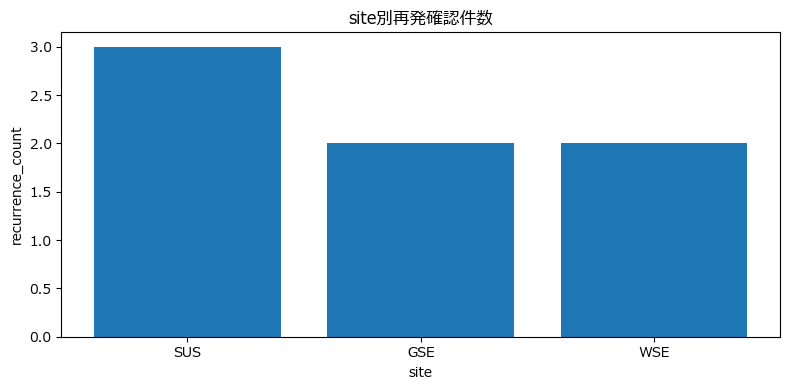

In [27]:
plt.figure(figsize=(8,4))

plt.bar(
    df_recurrence_summary["site"],
    df_recurrence_summary["recurrence_count"],
)

plt.title("site別再発確認件数")
plt.xlabel("site")
plt.ylabel("recurrence_count")

plt.tight_layout()
plt.show()